In [2]:
import numpy as np
import pandas as pd
import joblib
import optuna
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score, train_test_split
from category_encoders import TargetEncoder

from utils import (
    load_data, evaluate_model, save_metrics, plot_feature_importance,
    NUMERIC_FEATURES_TREES, MODELS_DIR
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("XGBoost version:", xgb.__version__)


XGBoost version: 3.2.0


Загрузка данных

In [3]:
X_train, X_test, y_train, y_test, _, _ = load_data()
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Числовые признаки для деревьев:", NUMERIC_FEATURES_TREES)


Train: (8819, 12) | Test: (2205, 12)
Числовые признаки для деревьев: ['area', 'rooms', 'floor', 'total_floors', 'minutes_to_metro', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_studio']


Препроцессор и фабрика пайплайнов

In [4]:
preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", NUMERIC_FEATURES_TREES),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["renovation"]),
    ("te",  TargetEncoder(cols=["metro_station"], smoothing=10.0), ["metro_station"]),
])

def make_pipeline(params: dict, n_estimators: int = 500) -> Pipeline:
    return Pipeline([
        ("prep", preprocessor),
        ("model", xgb.XGBRegressor(
            n_estimators=n_estimators,
            random_state=42,
            n_jobs=-1,
            tree_method="hist",  # быстрый алгоритм построения деревьев
            **params
        )),
    ])


Подбор гиперпараметров через Optuna

In [5]:
def objective(trial):
    params = {
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 1e-3, 5.0, log=True),
    }
    pipe = make_pipeline(params, n_estimators=500)
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    return -scores.mean()

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print("\nЛучшие гиперпараметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV MAE: {study.best_value:,.0f} руб.")


Best trial: 31. Best value: 9.93556e+06: 100%|██████████| 50/50 [01:33<00:00,  1.88s/it]


Лучшие гиперпараметры:
  learning_rate: 0.025887881051024957
  max_depth: 12
  min_child_weight: 2
  subsample: 0.6988435994083716
  colsample_bytree: 0.9299797020830202
  reg_alpha: 0.013960791961297526
  reg_lambda: 0.451815641067262
  gamma: 0.009704277361704892
Best CV MAE: 9,935,564 руб.


Финальное обучение с early stopping

In [6]:
# Выделяем валидационную выборку для early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

# Препроцессим вручную, чтобы передать eval_set в XGBoost
prep_final = ColumnTransformer(transformers=[
    ("num", "passthrough", NUMERIC_FEATURES_TREES),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["renovation"]),
    ("te",  TargetEncoder(cols=["metro_station"], smoothing=10.0), ["metro_station"]),
])
X_tr_enc  = prep_final.fit_transform(X_tr, y_tr)
X_val_enc = prep_final.transform(X_val)

model = xgb.XGBRegressor(
    n_estimators=2000,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=50,
    **best_params
)
model.fit(
    X_tr_enc, y_tr,
    eval_set=[(X_val_enc, y_val)],
    verbose=False
)
print(f"Оптимальное число деревьев (early stopping): {model.best_iteration + 1}")


Оптимальное число деревьев (early stopping): 394


Сборка финального пайплайна и оценка

In [7]:
# Собираем полный пайплайн с уже обученным препроцессором и моделью.
# Дообучаем препроцессор на ВСЁМ train, фиксируем n_estimators по результату early stopping.
final_params = dict(best_params)
final_pipeline = make_pipeline(final_params, n_estimators=model.best_iteration + 1)
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
metrics = evaluate_model(y_test, y_pred, "XGBoost")



=== XGBoost ===
  MAE  =       9,996,788 руб.
  RMSE =      25,679,265 руб.
  MAPE =          16.76 %
  R2   =         0.8680


Важность признаков

График сохранён: C:\Users\roman\PycharmProjects\real_estate_ML\reports\feature_importance_xgboost.png


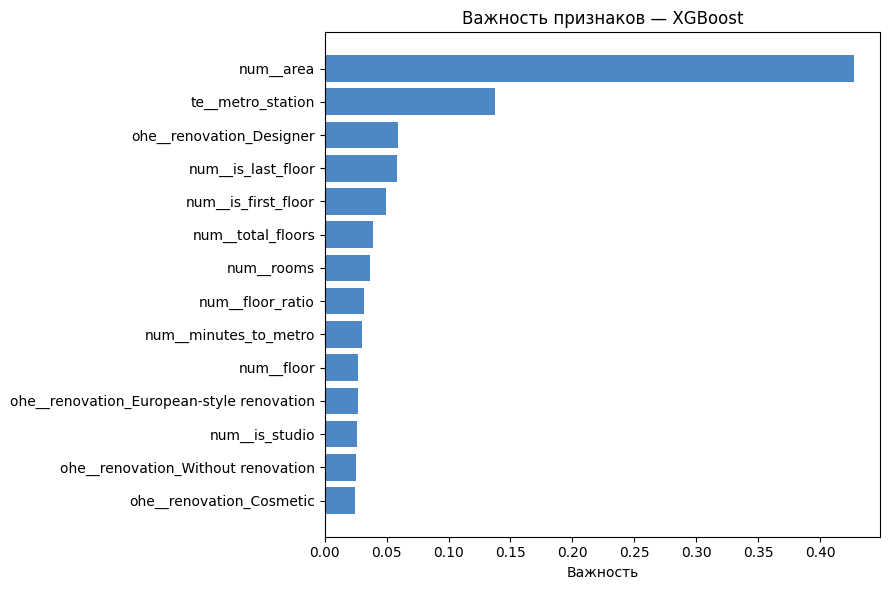

In [8]:
prep = final_pipeline.named_steps["prep"]
xgb_model = final_pipeline.named_steps["model"]
feature_names = prep.get_feature_names_out()

importance_df = plot_feature_importance(
    feature_names, xgb_model.feature_importances_, "XGBoost", top_n=15
)


Сохранение

In [9]:
# Сохраняем число итераций после early stopping вместе с гиперпараметрами
best_params_with_n = {**best_params, "n_estimators_after_early_stopping": int(model.best_iteration + 1)}

joblib.dump(final_pipeline, MODELS_DIR / "xgboost.pkl")
save_metrics("XGBoost", metrics, best_params=best_params_with_n)
print("Модель и метрики сохранены.")


Метрики сохранены в C:\Users\roman\PycharmProjects\real_estate_ML\ml_models\metrics.json
Модель и метрики сохранены.


Проверка инференса

In [10]:
from inference import predict_xgboost, predict_random_forest, predict_linear

example = {
    "area": 38.0, "rooms": 1.0, "floor": 5.0, "total_floors": 15,
    "minutes_to_metro": 20.0, "is_studio": 0,
    "metro_station": "Коломенская", "renovation": "Cosmetic",
}

print("=== Однушка на Коломенской ===")
print(f"  Linear:       {predict_linear(example):>15,.0f} руб.")
print(f"  RandomForest: {predict_random_forest(example):>15,.0f} руб.")
print(f"  XGBoost:      {predict_xgboost(example):>15,.0f} руб.")

example_center = {**example, "metro_station": "Китай-город"}
print("\n=== Та же квартира на Китай-городе ===")
print(f"  Linear:       {predict_linear(example_center):>15,.0f} руб.")
print(f"  RandomForest: {predict_random_forest(example_center):>15,.0f} руб.")
print(f"  XGBoost:      {predict_xgboost(example_center):>15,.0f} руб.")


=== Однушка на Коломенской ===
  Linear:            12,300,306 руб.
  RandomForest:      11,572,570 руб.
  XGBoost:           11,511,572 руб.

=== Та же квартира на Китай-городе ===
  Linear:            18,557,168 руб.
  RandomForest:      16,807,867 руб.
  XGBoost:           15,410,750 руб.
